# 06c — Deep Learning: LSTM Forecaster (Sliding Window)
**Objetivo:** Predecir consumo energético 24 horas adelante usando LSTM con ventana deslizante.  
**Diferencia vs Opción A:** El modelo recibe una secuencia de 168 horas (1 semana) como input `(batch, seq_len=168, features)`.  
**Comparación:** LSTM-Seq vs LSTM-Tabular vs MLP vs modelos previos.

## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import sys

sys.path.append('../src')

from modeling.DL_LSTM_seq import (
    set_seed,
    build_model,
    get_dataloaders,
    train_model,
    evaluate_model,
    save_model,
    load_model,
    DEVICE
)
from utils.metrics import calculate_metrics, print_metrics

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

FH         = 24
SEQ_LEN    = 168    # 1 semana de historia
TARGET_COL = 'PJME_MW'

Path('../reports/figures').mkdir(parents=True, exist_ok=True)

PyTorch version : 2.10.0+cpu
Device          : cpu


## 1. Cargar datos

In [2]:
data_dir = Path('../data/processed')

train_df = pd.read_csv(data_dir / f'train_{FH}hr.csv', index_col='Datetime', parse_dates=True)
val_df   = pd.read_csv(data_dir / f'val_{FH}hr.csv',   index_col='Datetime', parse_dates=True)
test_df  = pd.read_csv(data_dir / f'test_{FH}hr.csv',  index_col='Datetime', parse_dates=True)

train_df = train_df.asfreq('h')
val_df   = val_df.asfreq('h')
test_df  = test_df.asfreq('h')

print(f"Train : {train_df.shape}  {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"Val   : {val_df.shape}    {val_df.index[0].date()} → {val_df.index[-1].date()}")
print(f"Test  : {test_df.shape}   {test_df.index[0].date()} → {test_df.index[-1].date()}")

Train : (101622, 50)  2002-01-09 → 2013-08-13
Val   : (21752, 50)    2013-08-14 → 2016-02-06
Test  : (21753, 50)   2016-02-07 → 2018-08-02


## 2. DataLoaders + Scaler

In [3]:
train_loader, val_loader, test_loader, scaler_y_mean, scaler_y_std, feature_cols = get_dataloaders(
    train_df, val_df, test_df,
    target_col = TARGET_COL,
    seq_len    = SEQ_LEN,
    batch_size = 64,
)

# Verificar shape — debe ser (batch, seq_len=168, n_features)
sample_X, sample_y = next(iter(train_loader))
print(f"\nX shape : {sample_X.shape}  → (batch, seq_len, features)")
print(f"y shape : {sample_y.shape}  → (batch, 1)")
print(f"\nscaler_y_mean : {scaler_y_mean:.2f} MW")
print(f"scaler_y_std  : {scaler_y_std:.2f} MW")

seq_len         : 168 horas
n_features      : 50
Samples train   : 101454 | val: 21584 | test: 21585
X shape ejemplo : torch.Size([168, 50])  → (seq_len, n_features)

X shape : torch.Size([64, 168, 50])  → (batch, seq_len, features)
y shape : torch.Size([64, 1])  → (batch, 1)

scaler_y_mean : 32411.87 MW
scaler_y_std  : 6502.00 MW


## 3. Construir modelo

In [4]:
set_seed(22)

model = build_model(
    train_loader,
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.2,
)

Semilla fijada: 22
Arquitectura : LSTM(seq=168, features=50 → hidden=64, layers=2) → 1
Parámetros   : 63,041
Device       : cpu


## 4. Entrenamiento

In [ ]:
history = train_model(
    model,
    train_loader,
    val_loader,
    epochs    = 50,
    lr        = 1e-3,
    patience  = 10,
    save_path = '../models/dl_best_lstm_seq.pt',
)
## 88 min de entrenamiento

Epoch   1/50 | Train: 0.0434 | Val: 0.0108 | Best: 0.0108 | LR: 1.00e-03
Epoch  10/50 | Train: 0.0085 | Val: 0.0034 | Best: 0.0025 | LR: 1.00e-03
Epoch  20/50 | Train: 0.0075 | Val: 0.0018 | Best: 0.0018 | LR: 1.00e-03
Epoch  30/50 | Train: 0.0065 | Val: 0.0015 | Best: 0.0015 | LR: 5.00e-04
Epoch  40/50 | Train: 0.0060 | Val: 0.0013 | Best: 0.0013 | LR: 2.50e-04
Epoch  50/50 | Train: 0.0057 | Val: 0.0013 | Best: 0.0012 | LR: 1.25e-04

Mejor Val Loss: 0.0012 → guardado en ../models/dl_best_lstm_seq.pt


In [6]:
# Cargar modelo guardado — comentar bloque build_model si se usa esto
# model, scaler_y_mean, scaler_y_std, feature_cols, history = load_model(path='../models/dl_lstm_seq.pt')

### Curva de entrenamiento

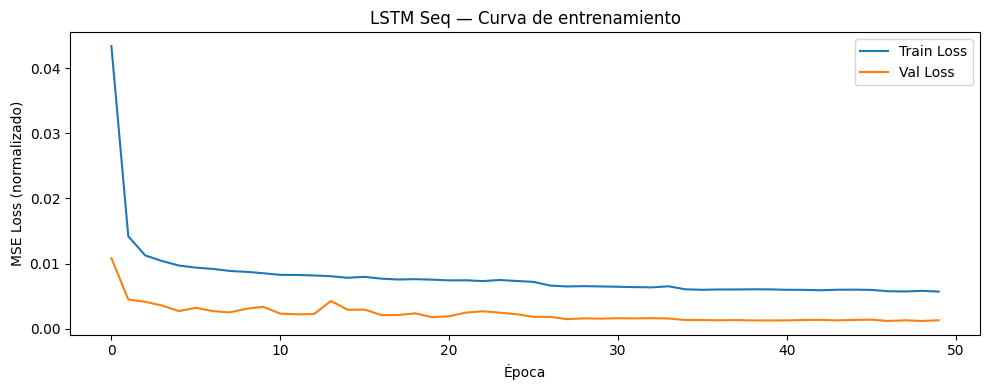

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'],   label='Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss (normalizado)')
ax.set_title('LSTM Seq — Curva de entrenamiento')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/dl_lstm_seq_training_curve.png', dpi=150)
plt.show()

## 5. Evaluación

In [8]:
model.load_state_dict(torch.load('../models/dl_best_lstm_seq.pt', map_location=DEVICE))

metrics_val,  y_true_val,  y_pred_val  = evaluate_model(model, val_loader,  scaler_y_mean, scaler_y_std, set_name='Val')
metrics_test, y_true_test, y_pred_test = evaluate_model(model, test_loader, scaler_y_mean, scaler_y_std, set_name='Test')


Métricas - Val
Mean_True:  31,493.72 MW
Std_True: 6,181.74 MW
MAE:  163.94 MW
RMSE: 223.93 MW
MAPE: 0.52%
R²:   0.9987


Métricas - Test
Mean_True:  31,055.78 MW
Std_True: 6,442.45 MW
MAE:  172.29 MW
RMSE: 233.90 MW
MAPE: 0.56%
R²:   0.9987



### Predicciones vs Real

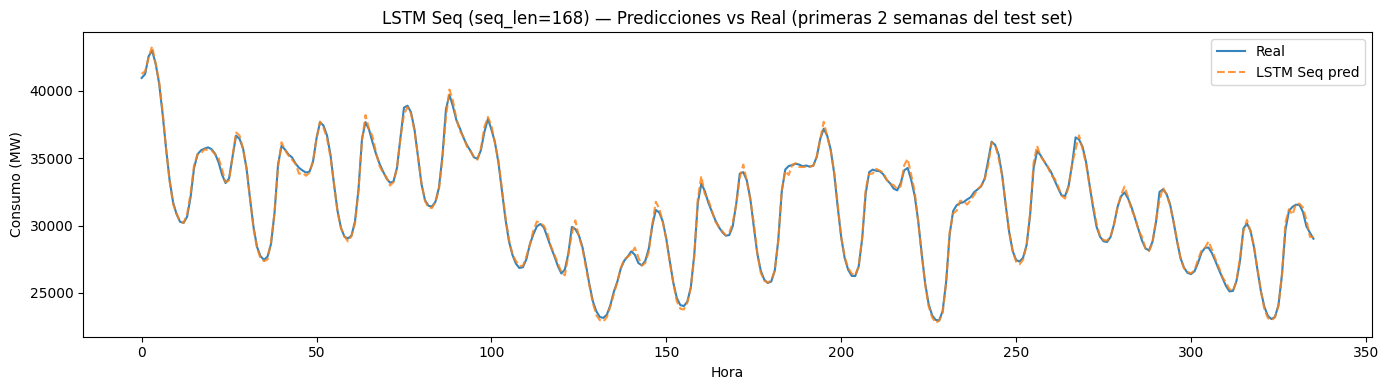

In [9]:
N = 24 * 14  # 2 semanas

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_true_test[:N], label='Real',          alpha=0.9)
ax.plot(y_pred_test[:N], label='LSTM Seq pred', alpha=0.8, linestyle='--')
ax.set_xlabel('Hora')
ax.set_ylabel('Consumo (MW)')
ax.set_title(f'LSTM Seq (seq_len={SEQ_LEN}) — Predicciones vs Real (primeras 2 semanas del test set)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/dl_lstm_seq_predictions.png', dpi=150)
plt.show()

## 6. Guardar modelo y resultados

In [10]:
save_model(
    model, scaler_y_mean, scaler_y_std, feature_cols,
    history = history,
    path    = '../models/dl_lstm_seq.pt'
)

metrics_test['model'] = 'LSTM_Seq'
results_df = pd.DataFrame([metrics_test])
results_df.to_csv('../reports/metrics/dl_lstm_seq_metrics.csv', index=False)
print(results_df.T)

Modelo guardado en ../models/dl_lstm_seq.pt
                      0
Mean_True  31055.776605
Std_True    6442.445488
MAE          172.292523
RMSE         233.896268
MAPE            0.55707
R2             0.998682
set                Test
model          LSTM_Seq


# Verificar Data Leakage

In [14]:
def verify_dataset(train_df, target_col='PJME_MW', seq_len=168):
    """
    Diagnóstico: verifica que el target es posterior a la ventana.
    Llama esto desde el notebook después de get_dataloaders.
    """
    from sklearn.preprocessing import StandardScaler

    all_cols   = [target_col] + [col for col in train_df.columns if col != target_col]
    train_arr  = train_df[all_cols].values

    scaler     = StandardScaler()
    train_scaled = scaler.fit_transform(train_arr)

    # Sample 0: ventana [0:seq_len] → target en [seq_len]
    ventana = train_scaled[0:seq_len, 0]        # columna target de la ventana
    target  = train_scaled[seq_len, 0]          # valor siguiente

    print(f"Último valor ventana (hora {seq_len})  : {ventana[-1]:.4f}")
    print(f"Target (hora {seq_len+1})              : {target:.4f}")
    print(f"¿Son distintos?                        : {ventana[-1] != target}")

    # Verificar en escala real
    last_mw  = ventana[-1]  * scaler.scale_[0] + scaler.mean_[0]
    target_mw = target      * scaler.scale_[0] + scaler.mean_[0]
    real_last  = train_df[target_col].iloc[seq_len - 1]
    real_target = train_df[target_col].iloc[seq_len]

    print(f"\nEn MW reales:")
    print(f"Último valor ventana : {last_mw:.2f} MW  (DataFrame iloc[{seq_len-1}]: {real_last:.2f} MW)")
    print(f"Target               : {target_mw:.2f} MW  (DataFrame iloc[{seq_len}]:   {real_target:.2f} MW)")
    print(f"¿Coinciden con DataFrame? : {abs(last_mw - real_last) < 1 and abs(target_mw - real_target) < 1}")


verify_dataset(train_df, target_col='PJME_MW', seq_len=168)


Último valor ventana (hora 168)  : -0.8348
Target (hora 169)              : -0.9654
¿Son distintos?                        : True

En MW reales:
Último valor ventana : 26984.00 MW  (DataFrame iloc[167]: 26984.00 MW)
Target               : 26135.00 MW  (DataFrame iloc[168]:   26135.00 MW)
¿Coinciden con DataFrame? : True


In [ ]:
print(f"scaler_y_mean           : {scaler_y_mean:.2f}")
print(f"train mean real         : {train_df['PJME_MW'].mean():.2f}")
print(f"test mean real:  {test_df['PJME_MW'].mean():.2f}")
print(f"dataset completo mean   : {pd.concat([train_df, val_df, test_df])['PJME_MW'].mean():.2f}")

# scaler_y_mean debe estar cerca de train mean, no del completo
print(' ')

print(f"expanding_mean train[0] : {train_df['expanding_mean'].iloc[0]:.2f}")
print(f"expanding_mean train[-1]: {train_df['expanding_mean'].iloc[-1]:.2f}")
print(f"expanding_mean test[0]  : {test_df['expanding_mean'].iloc[0]:.2f}")
print(f"PJME_MW mean total      : {pd.concat([train_df, val_df, test_df])['PJME_MW'].mean():.2f}")
# expanding_mean debe crecer progresivamente — train[0] < train[-1] < test[0]
# Si test[0] ≈ mean total → calculado sobre todo el dataset antes del split → leakage


naive_pred   = test_df['lag_168'].values
naive_true   = test_df['PJME_MW'].values
naive_metrics = calculate_metrics(naive_true, naive_pred, set_name='Naive_lag168')
print_metrics(naive_metrics)

scaler_y_mean           : 32411.87
train mean real         : 32411.87
dataset completo mean   : 32078.29
 
expanding_mean train[0] : 32729.67
expanding_mean train[-1]: 32411.99
expanding_mean test[0]  : 32251.13
PJME_MW mean total      : 32078.29

Métricas - Naive_lag168
Mean_True:  31,101.32 MW
Std_True: 6,446.03 MW
MAE:  3,760.93 MW
RMSE: 5,043.51 MW
MAPE: 11.83%
R²:   0.3878

